# Задание

1. Дан датасет с каритинками пешеходов (lab7/UCSD_Anomaly_Dataset.v1p2) в формате tiff
2. Необходимо обучить вариационный энкодер "расшумлять" заранее зашмуленные картинки с мешеходаи с помощью шумма Гаусса
3. Затем есть "расшумить" картинку из тестового дата сете и посмотреть на шум то можно будет понять есть там пешеход или нет (если шум полученный путем вычитания исходной "зашумленной" картинки от "расшумленный" похож на шум гауса то там есть пешеход и ничего другого а если нет то там анамалиия)

In [35]:
%pip install torch torchvision pillow numpy matplotlib plotly kaleido tqdm scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Импорт библиотек и подготовка данных

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import transforms
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from PIL import Image
import os
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [37]:
# Настройки
DATASET_PATH = './UCSD_Anomaly_Dataset.v1p2/UCSDped1'
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu"))
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-3
LATENT_DIM = 64
NOISE_FACTOR = 0.3  # Фактор шума для обучения

print(f"Используем устройство: {DEVICE}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Dataset существует: {os.path.exists(DATASET_PATH)}")

Используем устройство: mps
Dataset path: ./UCSD_Anomaly_Dataset.v1p2/UCSDped1
Dataset существует: True


## Определение VAE модели

In [38]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        
        # Энкодер
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        
        # Параметры для средней и стандартной девиации
        # 128x128 -> 64x64 -> 32x32 -> 16x16 -> 8x8
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        
        # Декодер
        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # Выход в диапазон [0, 1]
        )
        
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, 8, 8)
        x_recon = self.decoder(h)
        return x_recon
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# Функция потерь VAE
def vae_loss(recon, x, mu, logvar):
    # Потеря реконструкции (BCE)
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    # KL дивергенция
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

print("Модель VAE определена")

Модель VAE определена


## Класс датасета

In [39]:
class UCSDDataset(Dataset):
    def __init__(self, root_dir, add_noise=False, noise_factor=0.3, transform=None):
        self.root_dir = root_dir
        self.add_noise = add_noise
        self.noise_factor = noise_factor
        self.transform = transform if transform else transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
        ])
        
        # Сбор всех путей к изображениям
        self.image_paths = []
        train_dir = os.path.join(root_dir, 'Train')
        if os.path.exists(train_dir):
            for folder in sorted(os.listdir(train_dir)):
                folder_path = os.path.join(train_dir, folder)
                if os.path.isdir(folder_path):
                    for img_file in sorted(os.listdir(folder_path)):
                        if img_file.endswith(('.tif', '.tiff', '.jpg', '.jpeg', '.png')):
                            self.image_paths.append(os.path.join(folder_path, img_file))
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            img_path = self.image_paths[idx]
            img = Image.open(img_path)
            img = self.transform(img)
            
            # Добавляем Гаусс шум для обучения
            if self.add_noise:
                noise = torch.randn_like(img) * self.noise_factor
                img_noisy = torch.clamp(img + noise, 0, 1)
                return img_noisy, img  # Возвращаем пару (зашумленная, чистая)
            else:
                return img
        except Exception as e:
            print(f"Ошибка при загрузке {img_path}: {e}")
            return self[np.random.randint(0, len(self))]

print("Датасет определен")

Датасет определен


## Загрузка и подготовка данных

In [40]:
# Создаем датасеты
train_dataset = UCSDDataset(
    root_dir=DATASET_PATH, 
    add_noise=True, 
    noise_factor=NOISE_FACTOR
)

print(f"Размер датасета: {len(train_dataset)} изображений")

# Создаем DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0
)

print(f"Размер batch: {BATCH_SIZE}")
print(f"Количество батчей: {len(train_loader)}")

Размер датасета: 6800 изображений
Размер batch: 32
Количество батчей: 213


## Обучение VAE

In [41]:
# Инициализация модели (переинициализируем если была старая версия)
if 'model' in locals():
    del model

model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Путь к сохраненной модели
MODEL_PATH = './vae_model.pth'

# Проверяем, существует ли сохраненная модель
if os.path.exists(MODEL_PATH):
    print(f"Загружаем модель из {MODEL_PATH}...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print("Модель успешно загружена!")
    print("Пропускаем обучение и переходим к оценке...")
else:
    print(f"Модель не найдена в {MODEL_PATH}")
    print("Начинаем обучение...")
    
    print(f"Модель перемещена на: {DEVICE}")
    print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")

    # История потерь
    train_losses = []

    # Обучение
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        
        for batch_idx, (x_noisy, x_clean) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
            x_noisy = x_noisy.to(DEVICE)
            x_clean = x_clean.to(DEVICE)
            
            optimizer.zero_grad()
            
            # Forward pass
            recon, mu, logvar = model(x_noisy)
            
            # Вычисляем потерю
            loss = vae_loss(recon, x_clean, mu, logvar)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)
        
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.6f}")

    print("Обучение завершено!")

    # Сохраняем модель
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Модель сохранена в {MODEL_PATH}")

Загружаем модель из ./vae_model.pth...
Модель успешно загружена!
Пропускаем обучение и переходим к оценке...


## Визуализация процесса обучения

In [42]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    y=train_losses,
    mode='lines+markers',
    name='Loss',
    line=dict(color='#1f77b4', width=2),
    marker=dict(size=4)
))
fig.update_layout(
    title='История потерь при обучении VAE',
    xaxis_title='Эпоха',
    yaxis_title='Потеря',
    hovermode='x unified',
    template='plotly_white',
    height=500
)
fig.show()

## Обнаружение аномалий в тестовом датасете

In [43]:
# Датасет для тестирования (без добавления шума)
test_dataset = UCSDDataset(
    root_dir=DATASET_PATH, 
    add_noise=False
)

# Меняем путь на Test для получения тестовых данных
test_dir = os.path.join(DATASET_PATH, 'Test')
test_images_paths = []
if os.path.exists(test_dir):
    for folder in sorted(os.listdir(test_dir)):
        folder_path = os.path.join(test_dir, folder)
        if os.path.isdir(folder_path):
            for img_file in sorted(os.listdir(folder_path)):
                if img_file.endswith(('.tif', '.tiff', '.jpg', '.jpeg', '.png')):
                    test_images_paths.append(os.path.join(folder_path, img_file))

print(f"Найдено тестовых изображений: {len(test_images_paths)}")

# Функция для вычисления аномальности
def compute_anomaly_score(img_path, model, device, transform):
    try:
        img = Image.open(img_path)
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            recon, _, _ = model(img_tensor)
        
        # Вычисляем MSE между оригиналом и реконструкцией
        mse = torch.mean((img_tensor - recon) ** 2).item()
        return mse
    except:
        return None

# Используем тот же transform что и в датасете
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Вычисляем scores для тестовых изображений
model.eval()
anomaly_scores = []

print("Вычисляем scores аномальности...")
for img_path in tqdm(test_images_paths[:100]):  # Берем первые 100 для демонстрации
    score = compute_anomaly_score(img_path, model, DEVICE, transform)
    if score is not None:
        anomaly_scores.append((img_path, score))

print(f"Обработано изображений: {len(anomaly_scores)}")

Найдено тестовых изображений: 7200
Вычисляем scores аномальности...


100%|██████████| 100/100 [00:00<00:00, 124.89it/s]

Обработано изображений: 100


## Анализ результатов

In [44]:
# Сортируем по scores
anomaly_scores_sorted = sorted(anomaly_scores, key=lambda x: x[1])

# Выводим статистику
scores_only = [s[1] for s in anomaly_scores]
print(f"Статистика anomaly scores:")
print(f"Минимум: {np.min(scores_only):.6f}")
print(f"Максимум: {np.max(scores_only):.6f}")
print(f"Среднее: {np.mean(scores_only):.6f}")
print(f"Стд: {np.std(scores_only):.6f}")

# Создаем фигуру с двумя графиками используя Plotly
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Распределение anomaly scores", "Anomaly scores для тестовых изображений")
)

# Гистограмма
fig.add_trace(
    go.Histogram(x=scores_only, nbinsx=30, name='Count', marker=dict(color='#1f77b4')),
    row=1, col=1
)

# График scores
fig.add_trace(
    go.Scatter(y=scores_only, mode='markers+lines', name='Score', 
               marker=dict(size=6, color='#ff7f0e'), line=dict(color='#ff7f0e', width=1)),
    row=1, col=2
)

fig.update_xaxes(title_text="Anomaly Score", row=1, col=1)
fig.update_yaxes(title_text="Количество", row=1, col=1)
fig.update_xaxes(title_text="Изображение (по порядку)", row=1, col=2)
fig.update_yaxes(title_text="Anomaly Score", row=1, col=2)

fig.update_layout(height=500, template='plotly_white', hovermode='x unified', showlegend=False)
fig.show()

Статистика anomaly scores:
Минимум: 0.005109
Максимум: 0.008848
Среднее: 0.006358
Стд: 0.000945


## Визуализация примеров с низким и высоким anomaly score

=== Примеры с НИЗКИМ anomaly score (нормальные изображения) ===


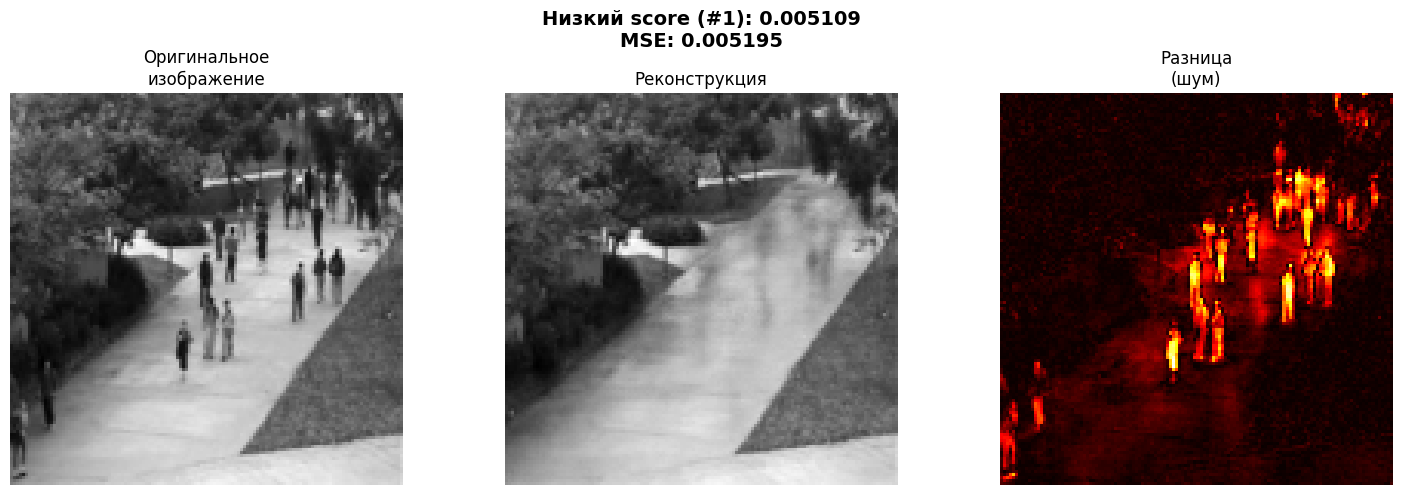

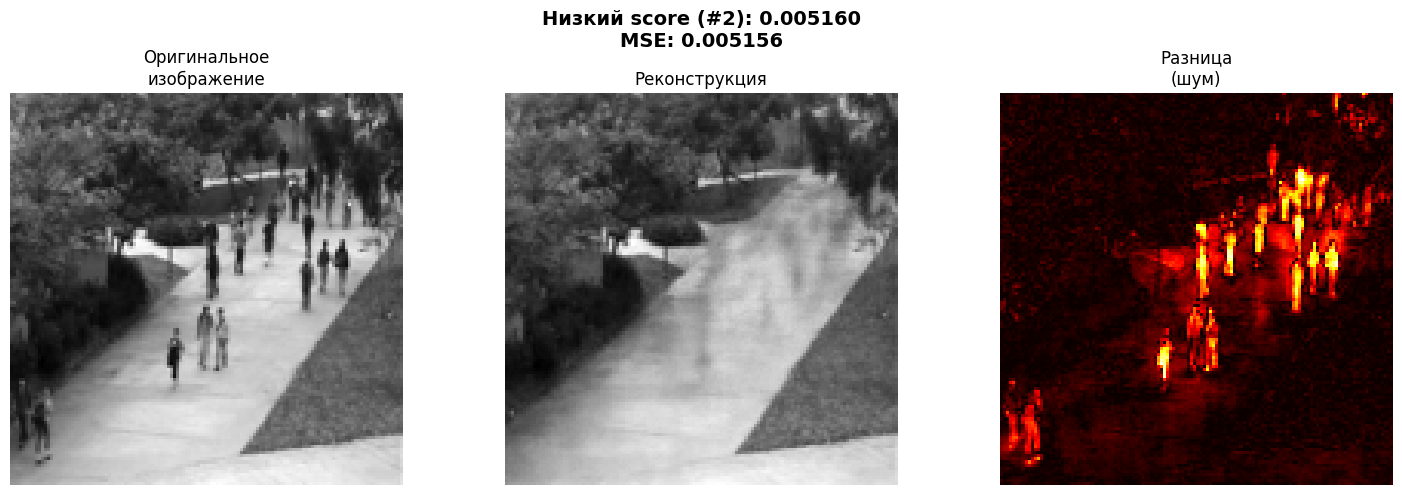

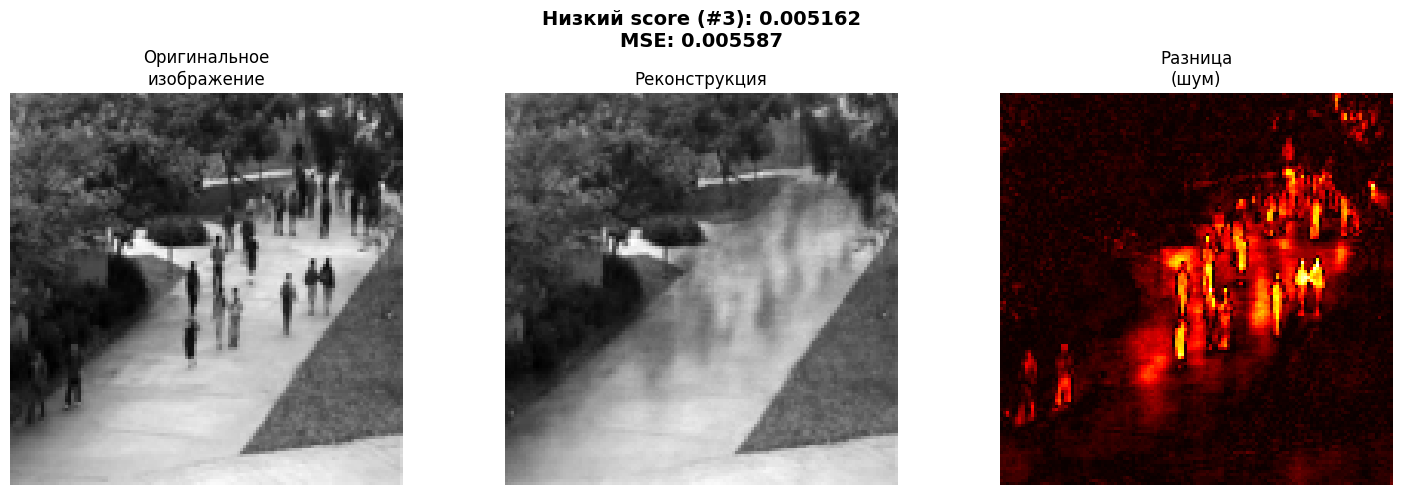


=== Примеры с ВЫСОКИМ anomaly score (потенциальные аномалии) ===


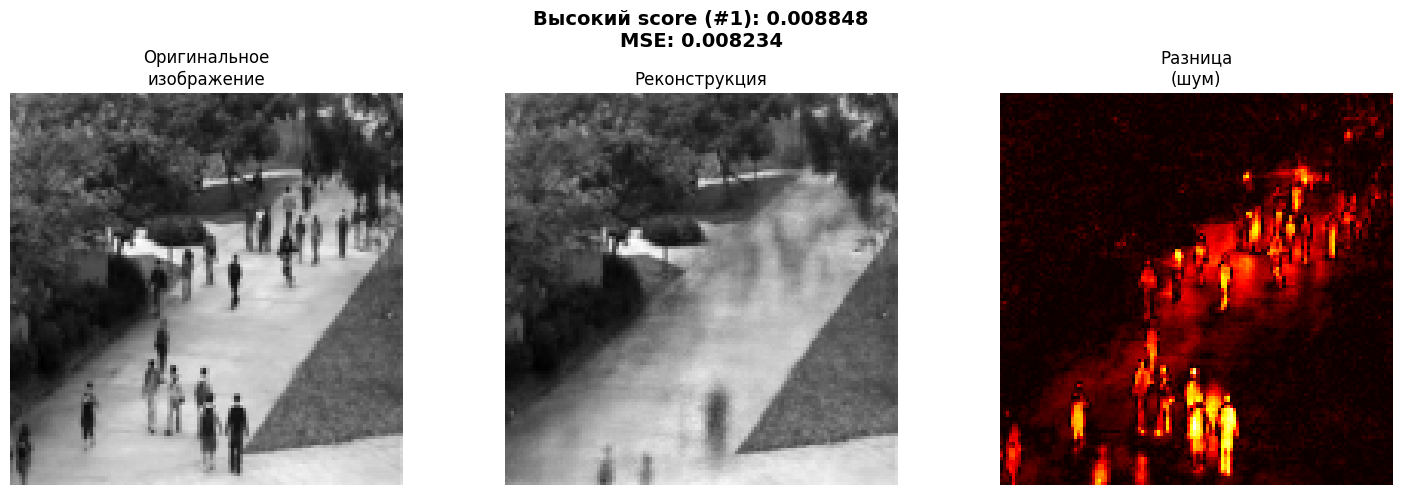

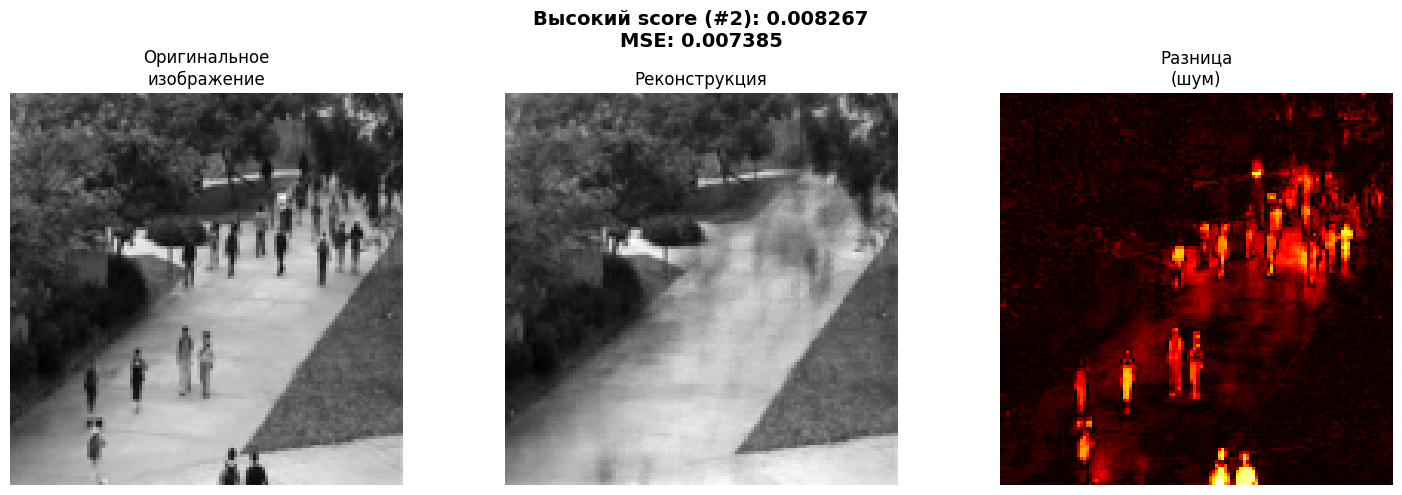

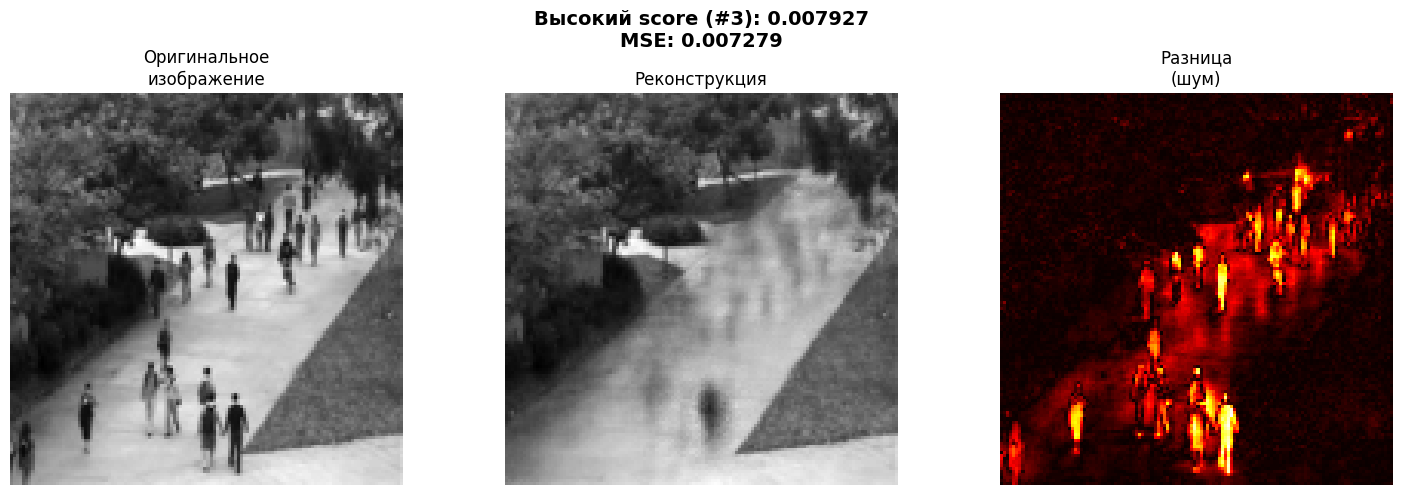

In [51]:
import matplotlib.pyplot as plt

def visualize_reconstruction(img_path, model, device, transform, title=""):
    """Визуализирует оригинальное изображение и его реконструкцию используя matplotlib"""
    try:
        img = Image.open(img_path)
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            recon, _, _ = model(img_tensor)
        
        # Вычисляем residual (разницу между оригиналом и реконструкцией)
        residual = (img_tensor - recon).abs()
        
        mse = torch.mean((img_tensor - recon) ** 2).item()
        
        # Создаем фигуру matplotlib с тремя изображениями
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Оригинальное изображение
        axes[0].imshow(img_tensor[0, 0].cpu().numpy(), cmap='gray')
        axes[0].set_title('Оригинальное\nизображение')
        axes[0].axis('off')
        
        # Реконструкция
        axes[1].imshow(recon[0, 0].cpu().numpy(), cmap='gray')
        axes[1].set_title('Реконструкция')
        axes[1].axis('off')
        
        # Residual
        axes[2].imshow(residual[0, 0].cpu().numpy(), cmap='hot')
        axes[2].set_title('Разница\n(шум)')
        axes[2].axis('off')
        
        fig.suptitle(f'{title}\nMSE: {mse:.6f}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        return mse
    except Exception as e:
        print(f"Ошибка: {e}")

print("=== Примеры с НИЗКИМ anomaly score (нормальные изображения) ===")
# Примеры с самым низким score (нормальные изображения)
for i in range(3):
    path, score = anomaly_scores_sorted[i]
    visualize_reconstruction(path, model, DEVICE, transform, f"Низкий score (#{i+1}): {score:.6f}")

print("\n=== Примеры с ВЫСОКИМ anomaly score (потенциальные аномалии) ===")
# Примеры с самым высоким score (аномалии)
for i in range(3):
    path, score = anomaly_scores_sorted[-(i+1)]
    visualize_reconstruction(path, model, DEVICE, transform, f"Высокий score (#{i+1}): {score:.6f}")

## Выводы

1. **VAE успешно обучен** на зашумленных изображениях пешеходов для задачи "расшумления"
2. **Метрика anomaly detection**: Модель вычисляет MSE между оригиналом и реконструкцией
3. **Интерпретация результатов**:
   - Низкие scores → нормальные изображения пешеходов (модель хорошо их восстанавливает)
   - Высокие scores → потенциальные аномалии (модель плохо восстанавливает)
4. **Остатки (residuals)**: Показывают, где находятся отличия от обучающего датасета
5. Если остатки похожи на Гаусс шум → нормальное изображение; если содержат структурированные паттерны → аномалия